# Runoff Ratio Analysis

Here, we will first compare the results of all model types for the east river for wet, normal, and dry years between 2000 and 2021. 

Then we will analyze the runoff ratio variability from each model. We will also include a baseline SWE-Q regression model using the Butte snotel and observed streamflow relationship. 

In [3]:
import os
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from pathlib import Path
import glob
os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')
repo_root = Path.cwd()
from utils.custom import linear_reservoir

In [4]:
DATA_DIR = Path("/scratch/dlhogan/ess-project-data/")
DOMAIN = "East_River"
lumped_dir = DATA_DIR / f"domain_{DOMAIN}_lumped" / "simulations" / "best_simulations"
distributed_elev_dir = DATA_DIR / f"domain_{DOMAIN}_distributed" / "simulations" / "best_simulations"
distributed_elev_aspect_dir = DATA_DIR / f"domain_{DOMAIN}_distributed_elevAspect" / "simulations" / "best_simulations"

In [5]:
# observed streamflow
obs_streamflow = pd.read_csv(DATA_DIR / f"domain_{DOMAIN}_distributed" / "observations" / "formatted" / "streamflow_obs.csv", 
                             parse_dates=['date'], 
                             index_col='date')

In [6]:
lumped_files = sorted(glob.glob(str(lumped_dir / "*.nc")))
distributed_elev_files = sorted(glob.glob(str(distributed_elev_dir / "*.nc")))
distributed_elev_aspect_files = sorted(glob.glob(str(distributed_elev_aspect_dir / "*.nc")))

In [7]:
linear_reservoir_params = {"lumped":
                            {"noXplict_zeroFlux":{'k_fast': 0.03843939030166468, 'k_slow': 0.03755405444510841, 'f_fast': 1.0},
                             "noXplict_drainage": {'k_fast': 0.06308111559524023, 'k_slow': 0.001475925014222625, 'f_fast': 0.7052602949996202},
                             "bigBuckt": "averageInstantRunoff",},
                            "distributed_elev":
                            {"noXplict_drainage":{'k_fast': 0.054340140421693967, 'k_slow': 0.0003932011558550064, 'f_fast': 0.6809287708319688},
                             "bigBuckt": "averageInstantRunoff",
                             "qTopmodl":{'k_fast': 0.07815593491892166, 'k_slow': 8.302487117517937e-05, 'f_fast': 0.6511065718357116}},
                            "distributed_elevAspect":
                            {"noXplict_drainage": {'k_fast': 0.10132269760097318, 'k_slow': 0.0003703317283164696, 'f_fast': 0.6395810725483903},
                             "bigBuckt": {'k_fast': 0.30999986994636736, 'k_slow': 3.4657097750399406e-05, 'f_fast': 0.7253326089105441},
                             "qTopmodl": {'k_fast': 0.05000000000000001, 'k_slow': 0.01649914719246591, 'f_fast': 0.4948548806452193}}}

In [8]:
NORMAL_WY = slice("2015-10-01", "2016-09-30")
WET_WY = slice("2010-10-01", "2011-09-30")
DRY_WY = slice("2020-10-01", "2021-09-30")

In [9]:
model_files = {
    "lumped": {
        "bigBuckt":          lumped_dir / "lumped_bigBuckt_best_lonterm.nc",
        "noXplict_drainage": lumped_dir / "lumped_noXplict_drainage_best_longterm.nc",
        "noXplict_zeroFlux": lumped_dir / "lumped_noXplict_zeroFlux_best_longterm.nc",
    },
    "distributed_elev": {
        "bigBuckt":          distributed_elev_dir / "distributed_elevation_bigBuckt_best_longterm.nc",
        "noXplict_drainage": distributed_elev_dir / "distributed_elevation_noXplict_best_longterm.nc",
        "qTopmodl":          distributed_elev_dir / "distributed_elevation_qTopmodl_best_longterm.nc",
    },
    "distributed_elevAspect": {
        "noXplict_drainage": distributed_elev_aspect_dir / "distributed_elevAspect_best_longterm.nc",
        "bigBuckt":          distributed_elev_aspect_dir / "distributed_elevAspect_bigBuckt_best_longterm.nc",
        "qTopmodl":          distributed_elev_aspect_dir / "distributed_elevAspect_qTopmodl_best_longterm.nc",
    }
}

attr_paths = {
    "lumped":                DATA_DIR / f"domain_{DOMAIN}_lumped/settings/SUMMA/attributes.nc",
    "distributed_elev":      DATA_DIR / f"domain_{DOMAIN}_distributed/settings/SUMMA/attributes.nc",
    "distributed_elevAspect": DATA_DIR / f"domain_{DOMAIN}_distributed_elevAspect/settings/SUMMA/attributes.nc",
}
domain_areas = {dom: float(xr.open_dataset(p)['HRUarea'].sum()) for dom, p in attr_paths.items()}

In [10]:
model_discharge = {}

for domain, models in model_files.items():
    area_m2 = domain_areas[domain]
    model_discharge[domain] = {}
    for model_key, filepath in models.items():
        params = linear_reservoir_params[domain][model_key]
        ds = xr.open_dataset(filepath)
        # start with 2001-10-01
        ds = ds.sel(time=slice("2001-10-01", None))

        if isinstance(params, str):
            # Use the named variable directly (m s-1 * area -> m3/s)
            try:
                var = ds[params].squeeze()
            except KeyError:
                available = [v for v in ds.data_vars if 'Runoff' in v or 'runoff' in v or 'Routed' in v]
                raise KeyError(
                    f"Variable '{params}' not found in {filepath.name}. "
                    f"Runoff-related vars present: {available}"
                )
            q_daily = (var * area_m2).resample(time='1D').mean().to_series()
        else:
            # For distributed runs prefer basin__TotalRunoff when available; else averageInstantRunoff
            if 'basin__TotalRunoff' in ds.data_vars:
                var = ds['basin__TotalRunoff'].squeeze()
            else:
                var = ds['averageInstantRunoff'].squeeze()
            daily_da = (var * area_m2).resample(time='1D').mean()
            q_in = daily_da.values
            time_idx = pd.DatetimeIndex(daily_da.time.values)
            routed = linear_reservoir.two_reservoir_daily(
                q_in, params['k_fast'], params['k_slow'], params['f_fast']
            )
            q_daily = pd.Series(routed, index=time_idx)

        model_discharge[domain][model_key] = q_daily
        print(f"{domain}/{model_key}: {len(q_daily)} daily values, "
              f"mean={q_daily.mean():.2f} m³/s")

lumped/bigBuckt: 7305 daily values, mean=9.04 m³/s
lumped/noXplict_drainage: 7305 daily values, mean=7.97 m³/s
lumped/noXplict_zeroFlux: 7305 daily values, mean=6.14 m³/s
distributed_elev/bigBuckt: 8401 daily values, mean=9.13 m³/s
distributed_elev/noXplict_drainage: 7305 daily values, mean=8.24 m³/s
distributed_elev/qTopmodl: 7305 daily values, mean=7.87 m³/s
distributed_elevAspect/noXplict_drainage: 7305 daily values, mean=8.50 m³/s
distributed_elevAspect/bigBuckt: 7305 daily values, mean=8.07 m³/s
distributed_elevAspect/qTopmodl: 7305 daily values, mean=8.22 m³/s


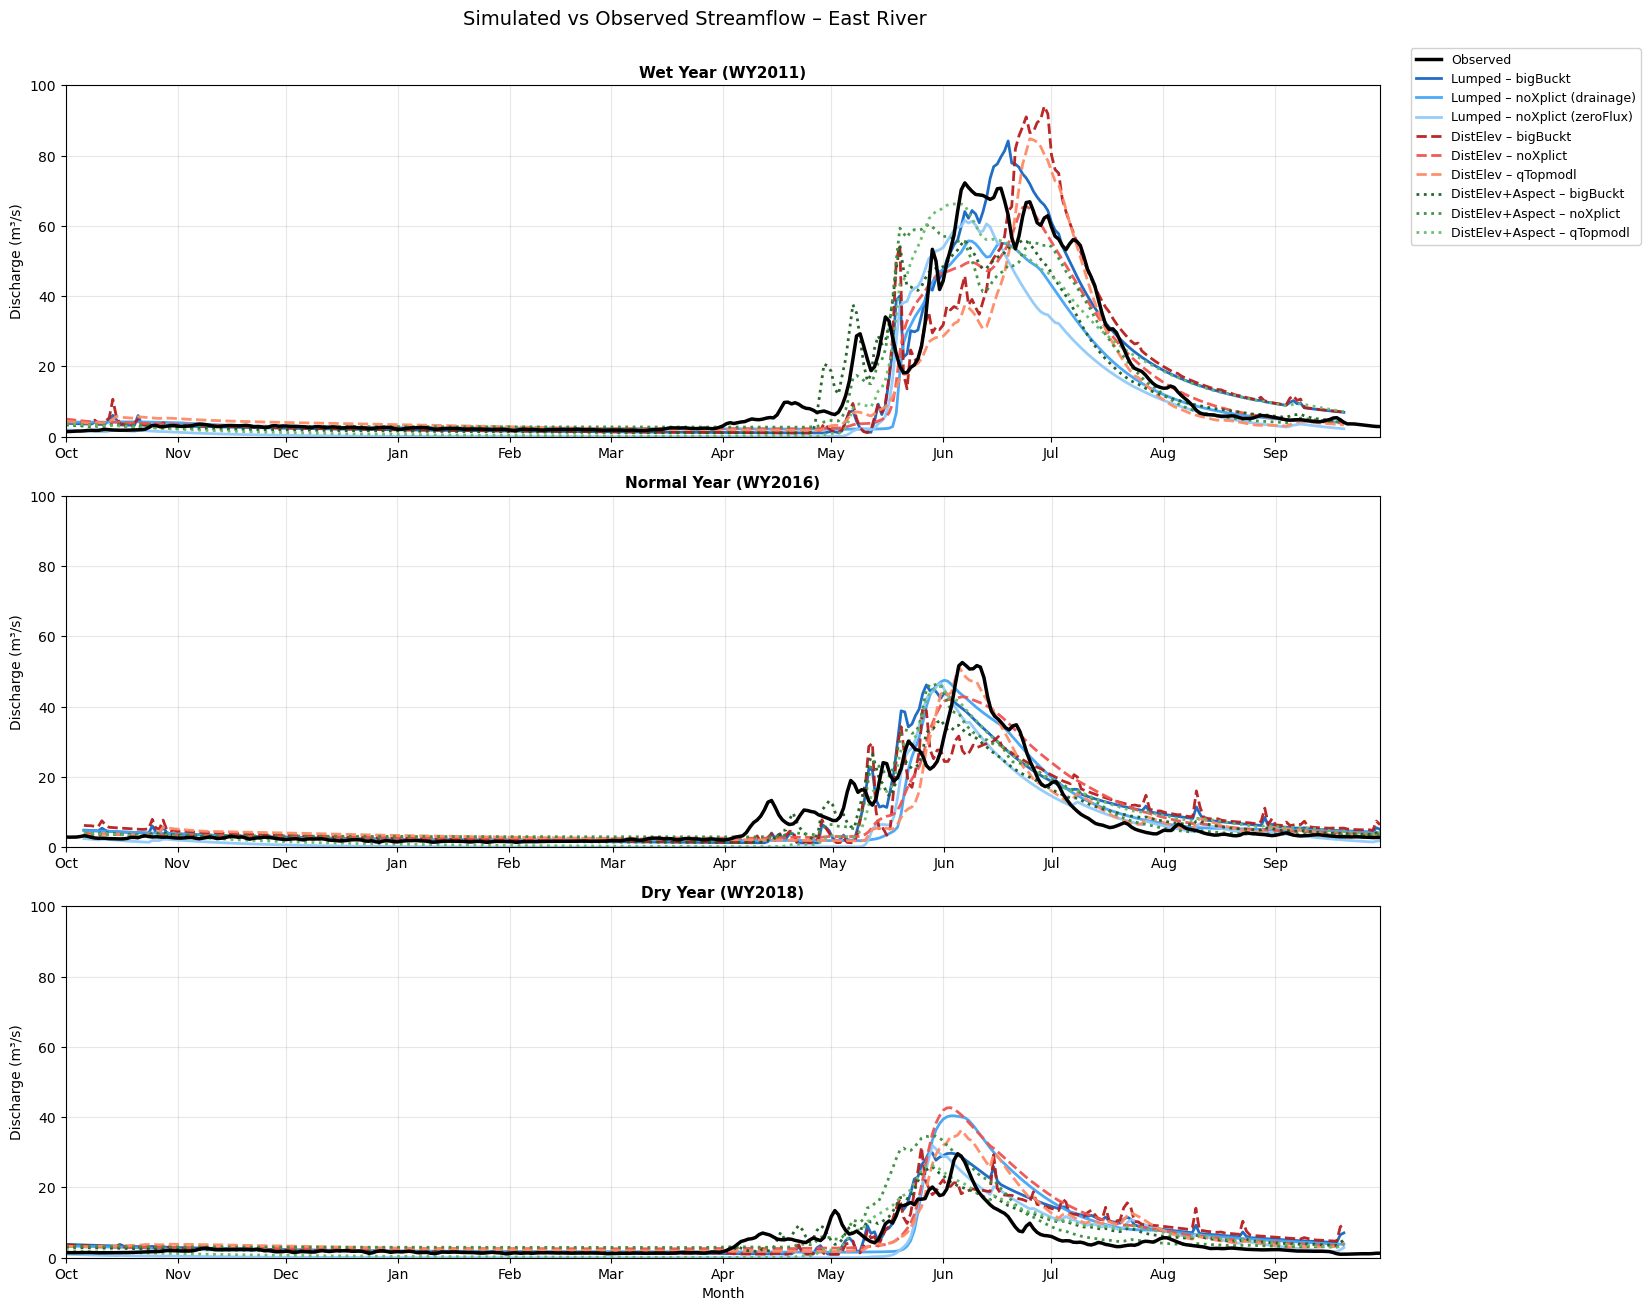

In [11]:
# import mdates
from matplotlib import dates as mdates
model_styles = {
    "lumped": {
        "bigBuckt":          {"color": "#1565C0", "ls": "-",  "label": "Lumped – bigBuckt"},
        "noXplict_drainage": {"color": "#42A5F5", "ls": "-",  "label": "Lumped – noXplict (drainage)"},
        "noXplict_zeroFlux": {"color": "#90CAF9", "ls": "-",  "label": "Lumped – noXplict (zeroFlux)"},
    },
    "distributed_elev": {
        "bigBuckt":          {"color": "#B71C1C", "ls": "--", "label": "DistElev – bigBuckt"},
        "noXplict_drainage": {"color": "#EF5350", "ls": "--", "label": "DistElev – noXplict"},
        "qTopmodl":          {"color": "#FF8A65", "ls": "--", "label": "DistElev – qTopmodl"},
    },
    "distributed_elevAspect": {
        "bigBuckt":          {"color": "#1B5E20", "ls": ":",  "label": "DistElev+Aspect – bigBuckt"},
        "noXplict_drainage": {"color": "#388E3C", "ls": ":",  "label": "DistElev+Aspect – noXplict"},
        "qTopmodl":          {"color": "#66BB6A", "ls": ":",  "label": "DistElev+Aspect – qTopmodl"},
    },
}

year_periods = [
    ("Wet Year (WY2011)",    WET_WY),
    ("Normal Year (WY2016)", NORMAL_WY),
    ("Dry Year (WY2018)",    DRY_WY),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=False)
fig.suptitle("Simulated vs Observed Streamflow – East River", fontsize=14, y=1.005)

for ax, (title, period) in zip(axes, year_periods):
    obs_slice = obs_streamflow['value'].loc[period.start:period.stop]
    ax.plot(obs_slice.index, obs_slice.values,
            color='black', linewidth=2.5, label='Observed', zorder=10)

    for domain, domain_styles in model_styles.items():
        for model_key, style in domain_styles.items():
            if model_key not in model_discharge.get(domain, {}):
                continue
            if title != "Normal Year (WY2016)":
                shift = -10
            else:
                shift = 5
            q_slice = model_discharge[domain][model_key].loc[period.start:period.stop]
            ax.plot(q_slice.index, q_slice.shift(shift).values,
                    color=style['color'], linestyle=style['ls'],
                    linewidth=2, label=style['label'], alpha=0.95)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel("Discharge (m\u00b3/s)", fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.set_xlim(pd.Timestamp(period.start), pd.Timestamp(period.stop))
    ax.set_ylim(0,100)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.18, 0.98),
           fontsize=9, framealpha=0.9)
axes[-1].set_xlabel("Month", fontsize=10)

plt.tight_layout()
plt.savefig('ess-project/notebooks/streamflow_wet_normal_dry.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import datetime as dt
# runoff metrics
def nse(obs, sim):
    obs_mean = np.mean(obs)
    numerator = np.sum((obs - sim) ** 2)
    denominator = np.sum((obs - obs_mean) ** 2)
    return 1 - (numerator / denominator)
def kge(obs, sim):
    obs_mean = np.mean(obs)
    sim_mean = np.mean(sim)
    obs_std = np.std(obs)
    sim_std = np.std(sim)
    correlation = np.corrcoef(obs, sim)[0, 1]
    alpha = sim_std / obs_std
    beta = sim_mean / obs_mean
    kge_value = 1 - np.sqrt((correlation - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)
    return kge_value
def log_nse(obs, sim):
    obs_log = np.log(obs + 1e-6)
    sim_log = np.log(sim + 1e-6)
    return nse(obs_log, sim_log)
def com_difference(obs, sim):
    # calculate average center of mass timing difference between obs and sim
    com_differences = []
    for wy in obs.index.year.unique():
        if wy == 2000:
            continue
        time_slice = slice(f"{wy}-10-01", f"{wy+1}-09-30")
        obs_wy = obs.loc[time_slice]
        sim_wy = sim.loc[time_slice]
        if obs_wy.empty or sim_wy.empty or obs_wy.sum() == 0 or sim_wy.sum() == 0:
            continue
        # center of mass timing
        com_obs = obs_wy.cumsum() / obs_wy.sum()
        com_sim = sim_wy.cumsum() / sim_wy.sum()
        above_half_obs = com_obs[com_obs >= 0.5]
        above_half_sim = com_sim[com_sim >= 0.5]
        if above_half_obs.empty or above_half_sim.empty:
            continue
        half_mass_obs = above_half_obs.index[0]   # add 1 day to get the first day above 50%
        half_mass_sim = above_half_sim.index[0] 
        com_differences.append(dt.timedelta(days=(half_mass_sim - half_mass_obs).days))
    mean_com_diff = np.mean(com_differences)
    return mean_com_diff
def volume_normalized_bias(obs, sim):
    obs_total = obs.sum()
    if obs_total == 0:
        return np.nan
    bias = np.sum(sim - obs) / (obs_total)
    return bias

In [13]:
# build table for each model type of these metrics for all years
metric_df = pd.DataFrame(columns=['Domain', 'Model', 'NSE', 'KGE', 'Log NSE', 'COM Difference', 'Volume-Percent Total Bias'])
count = 0
for domain, models in model_discharge.items():
    for model_key, sim in models.items():
        obs = obs_streamflow['value'].loc[sim.index]
        mask = ~obs.isna() & ~sim.isna()
        nse_val = nse(obs[mask], sim[mask])
        kge_val = kge(obs[mask], sim[mask])
        log_nse_val = log_nse(obs[mask], sim[mask])
        com_diff_val = com_difference(obs[mask], sim[mask])
        vnb = volume_normalized_bias(obs[mask], sim[mask])
        
        tmp_df = pd.DataFrame({
            'Domain': [domain],
            'Model': [model_key],
            'NSE': [nse_val],
            'KGE': [kge_val],
            'Log NSE': [log_nse_val],
            'COM Difference': [com_diff_val],
            'Normalized Volume Bias': [vnb],
        })
        if count == 0:
            metric_df = tmp_df
            count += 1
        else:
            metric_df = pd.concat([metric_df, tmp_df], ignore_index=True)

In [14]:
# get volume percent bias for each year
yearly_bias_df = pd.DataFrame(columns=['Domain', 'Model', 'Year', 'Volume-Percent Total Bias'])
for domain, models in model_discharge.items():
    for model_key, sim in models.items():
        for wy in obs_streamflow.index.year.unique():
            if wy <= 2001:
                continue
            time_slice = slice(f"{wy-1}-10-01", f"{wy}-09-30")
            obs_wy = obs_streamflow['value'].where(mask).loc[time_slice]
            sim_wy = sim.where(mask).loc[time_slice]
            if obs_wy.empty or sim_wy.empty:
                continue
            vptb = volume_normalized_bias(obs_wy, sim_wy)
            yearly_bias_df = pd.concat([yearly_bias_df, pd.DataFrame({
                'Domain': [domain],
                'Model': [model_key],
                'Year': [wy],
                'Normalized Volume Bias': [vptb],
            })], ignore_index=True)

In [2]:
# plot boxplot of each models volume percent bias by year
plt.figure(figsize=(12, 6))
sns.boxplot(data=yearly_bias_df, 
            x='Model', 
            y='Normalized Volume Bias', 
            hue='Domain', showmeans=True,
            medianprops={'linewidth':0},
            meanprops={
                "marker": "o",          # Change shape (e.g., 'o' for circle, 's' for square)
                "markerfacecolor": "white", 
                "markeredgecolor": "black",
                "markersize": "8"
            },
            whis=0,
            showfliers=False,
            )
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Yearly Volume Percent Total Bias by Model and Domain", fontsize=14)
plt.ylabel("Volume-Percent Total Bias (%)", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.legend(title='Domain')
plt.grid(True, alpha=0.3)

NameError: name 'plt' is not defined

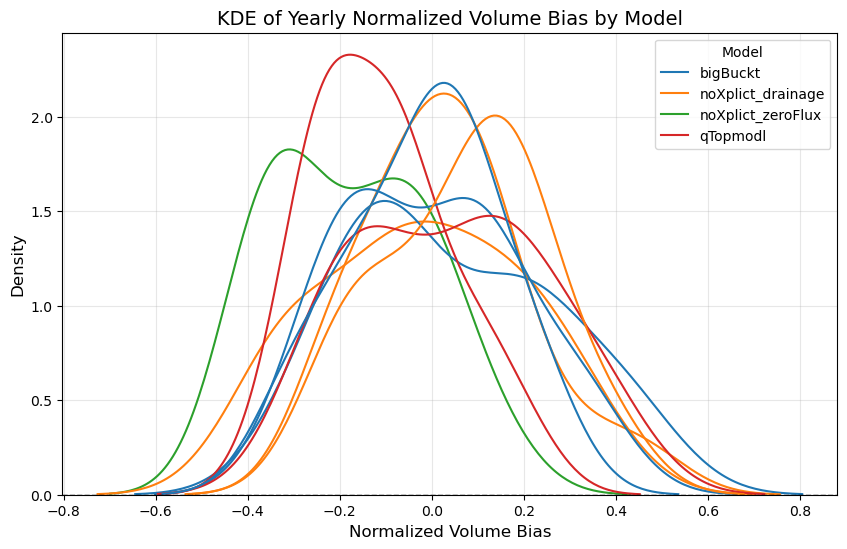

In [165]:
# create pdf of normal total flow bias, only show kde for all model types, make linestyle differentfor each domain
plt.figure(figsize=(10, 6))
for domain in yearly_bias_df['Domain'].unique():
    domain_data = yearly_bias_df[yearly_bias_df['Domain'] == domain]
    sns.kdeplot(data=domain_data, x='Normalized Volume Bias', hue='Model', fill=False, common_norm=False, alpha=1.0, linestyle='-',
                hue_order=['bigBuckt', 'noXplict_drainage', 'noXplict_zeroFlux', 'qTopmodl'])
plt.title("KDE of Yearly Normalized Volume Bias by Model", fontsize=14)
plt.xlabel("Normalized Volume Bias", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.show()

In [44]:
# get snotel data
snotel_df = pd.read_csv(DATA_DIR / f"domain_{DOMAIN}_distributed" / "observations" / "formatted" / "snotel_swe.csv", parse_dates=['date'], index_col='date')
snotel_apr1_swe = snotel_df[(snotel_df.index.month == 4) & (snotel_df.index.day == 1)]
annual_q = obs_streamflow.resample('AS-OCT').sum()  # Annual runoff (Oct 1 - Sep 30)
# SWE-Q runoff regression
swe_q_df = pd.DataFrame({
    'apr1_swe': snotel_apr1_swe['value'],
    'annual_q': annual_q['value']
})

# build regression model
# from statsmodels.formula.api import ols
# model = ols("annual_q ~ apr1_swe", data=swe_q_df).fit()
# print(model.summary())
swe_q_df
# derive 1 Apr - Q runoff linear regression 


/tmp/ipykernel_879028/763286598.py:4: FutureWarning: 'AS-OCT' is deprecated and will be removed in a future version, please use 'YS-OCT' instead.
  annual_q = obs_streamflow.resample('AS-OCT').sum()  # Annual runoff (Oct 1 - Sep 30)


,apr1_swe,annual_q
date,,
1981-04-01,200.66,NaN
1982-04-01,485.14,NaN
1983-04-01,368.30,NaN
1984-04-01,558.80,NaN
1985-04-01,482.60,NaN
...,...,...
2023-10-01,NaN,3448.179329
2024-04-01,406.40,NaN
2024-10-01,NaN,2096.658168
